<a href="https://colab.research.google.com/github/SANDULFERNANDO/Stellarx-Diagnostic-System/blob/feature%2FResNet50-Model/ResNet50Model_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import json
import os

from tensorflow.keras import layers, models

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [11]:
DATASET_PATH = "/content/drive/MyDrive/dataset"

TRAIN_PATH = os.path.join(DATASET_PATH, "Train")
VAL_PATH = os.path.join(DATASET_PATH, "Validation")
TEST_PATH = os.path.join(DATASET_PATH, "Test")

In [9]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 123
NUM_CLASSES = 3

In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

Found 2680 files belonging to 3 classes.


In [13]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_PATH,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 574 files belonging to 3 classes.


In [14]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 573 files belonging to 3 classes.


In [15]:
class_names = train_ds.class_names

print(class_names)

['Eczema', 'Leishmaniasis', 'Tinea']


In [17]:
class_mapping = {
    i: name for i, name in enumerate(class_names)
}

with open(
    "/content/drive/MyDrive/dataset/class_names2.json",
    "w"
) as f:
    json.dump(class_mapping, f, indent=4)

In [18]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1),

    layers.RandomContrast(0.1)

])

In [19]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [20]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)


base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
inputs = tf.keras.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3)
)


x = data_augmentation(inputs)


x = preprocess_input(x)


x = base_model(
    x,
    training=False
)


x = layers.GlobalAveragePooling2D()(x)


outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)


model = tf.keras.Model(
    inputs,
    outputs
)

In [22]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 3)         │      6,147 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [23]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [24]:
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=20

)

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 544s 6s/step - accuracy: 0.8108 - loss: 0.4980 - val_accuracy: 0.9251 - val_loss: 0.2276
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 423s 5s/step - accuracy: 0.9534 - loss: 0.1505 - val_accuracy: 0.9443 - val_loss: 0.1639
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 407s 5s/step - accuracy: 0.9694 - loss: 0.1016 - val_accuracy: 0.9530 - val_loss: 0.1441
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 417s 5s/step - accuracy: 0.9799 - loss: 0.0759 - val_accuracy: 0.9530 - val_loss: 0.1273
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 412s 5s/step - accuracy: 0.9851 - loss: 0.0624 - val_accuracy: 0.9599 - val_loss: 0.1213
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 396s 5s/step - accuracy: 0.9869 - loss: 0.0535 - val_accuracy: 0.9669 - val_loss: 0.1014
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 411s 5s/step - accuracy: 0.9866 - loss: 0.0483 - val_accuracy: 0.9686 - val_loss: 0.0975
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 444s 5s/step - accuracy: 0.9896 - loss: 0.0411 - val_accuracy: 0.9669 - v

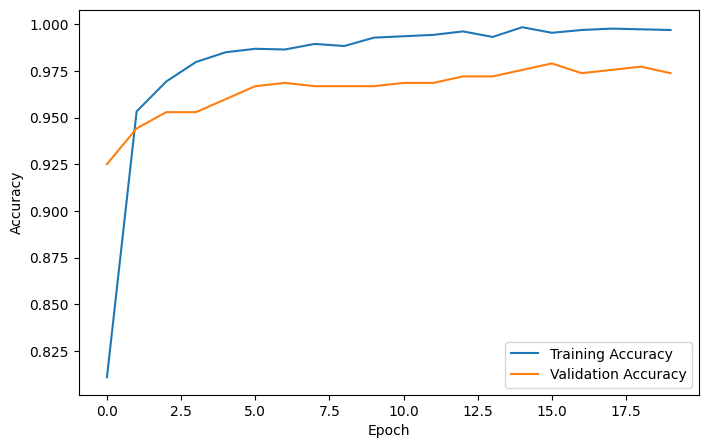

In [25]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

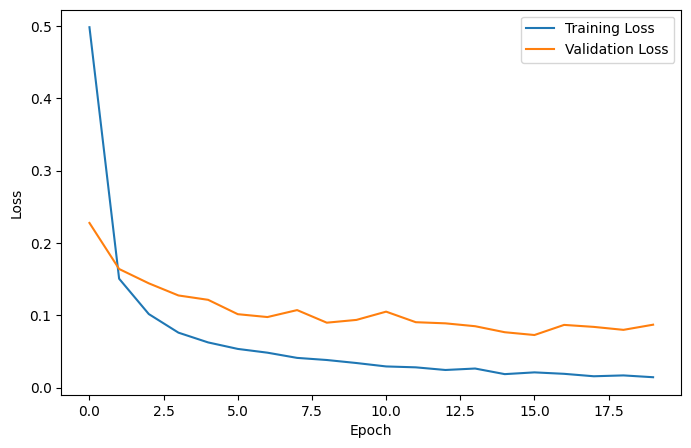

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [27]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(
    "Test Accuracy:",
    test_accuracy
)

print(
    "Test Loss:",
    test_loss
)

18/18 ━━━━━━━━━━━━━━━━━━━━ 97s 5s/step - accuracy: 0.9756 - loss: 0.0641
Test Accuracy: 0.9755671620368958
Test Loss: 0.06408736854791641


In [28]:
y_true = []
y_pred = []


for images, labels in test_ds:

    predictions = model.predict(images)

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


In [29]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

               precision    recall  f1-score   support

       Eczema       0.99      0.99      0.99       232
Leishmaniasis       0.96      0.91      0.94       113
        Tinea       0.97      0.99      0.98       228

     accuracy                           0.98       573
    macro avg       0.97      0.96      0.97       573
 weighted avg       0.98      0.98      0.98       573



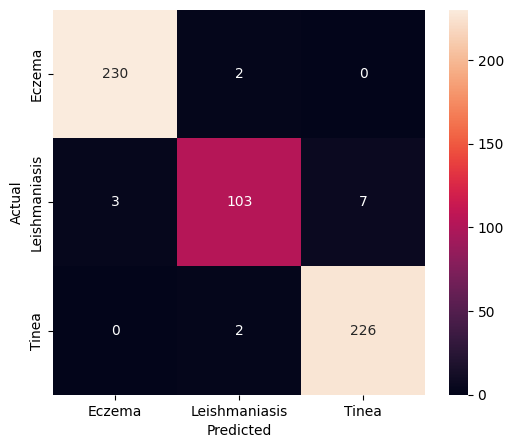

In [30]:
cm = confusion_matrix(
    y_true,
    y_pred
)


plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [31]:
model.save(
    "/content/drive/MyDrive/dataset/resnet50_model2.keras"
)